# Week 2 Exercises

## Mathematical exercises: Pinhole camera

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import sys
sys.path.append('..')
from CV_functions import box3d, Pi, PiInv, projectpoints

### Ex 2.1

All points in bounds: False
Points out of bounds: 20
P1 projects to: [[100. 220.]]


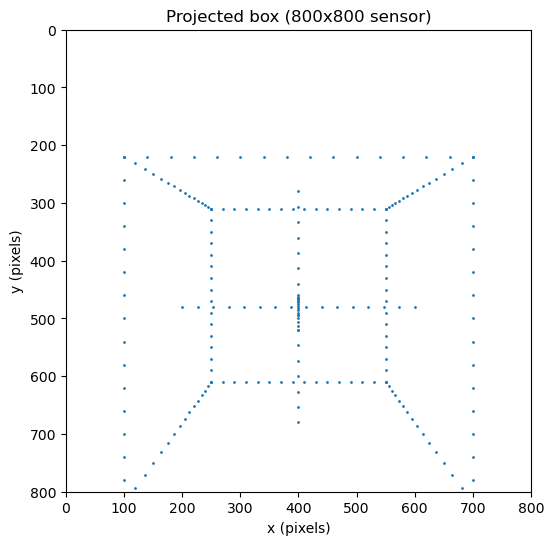

In [ ]:
# Camera parameters
f = 600
delta_x = 400
delta_y = 400
K = np.array([[f, 0, delta_x],
              [0, f, delta_y],
              [0, 0,   1]])

R = np.eye(3)
t = np.array([0, 0.2, 1.5])

# Project the box
Q = box3d()
projected = projectpoints(K, R, t, Q)

# Check if all points are within the 800x800 image
in_bounds = (projected[0] >= 0) & (projected[0] <= 800) & \
            (projected[1] >= 0) & (projected[1] <= 800)
print(f"All points in bounds: {in_bounds.all()}")
print(f"Points out of bounds: {(~in_bounds).sum()}")

# Where does P1 = [-0.5, -0.5, -0.5] project to?
P1 = np.array([[-0.5], [-0.5], [-0.5]])
p1_proj = projectpoints(K, R, t, P1)
print(f"P1 projects to: {p1_proj.T}") # Should be [100, 220]

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(projected[0], projected[1], s=1)
plt.xlim(0, 800)
plt.ylim(0, 800)
plt.title('Projected box (800x800 sensor)')
plt.xlabel('x (pixels)')
plt.ylabel('y (pixels)')
plt.show()

### Ex 2.2

All points in bounds: True
Points out of bounds: 0
P1 projects to: [[120.4  232.24]]


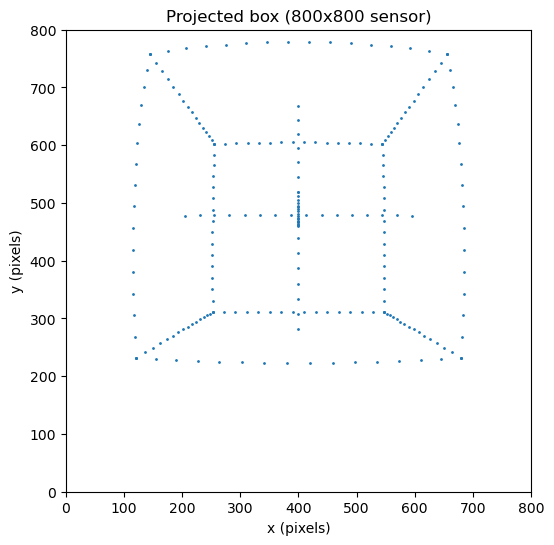

In [15]:
def projectpoints(K: np.ndarray, R: np.ndarray, t: np.ndarray, Q: np.ndarray, distCoeffs: np.ndarray) -> np.ndarray:
    '''
    Camera matrix K
    Pose of the camera (R)otation, (t)ranslation
    3xn matrix Q, which is n points in 3D to be projected
    '''
    t = t.reshape(3, 1)
    Qc = R @ Q + t
    xy = Pi(Qc)
    r = np.sqrt(xy[0]**2 + xy[1]**2)
    delta_r = sum([k * r**((i+1)*2) for i, k in enumerate(distCoeffs)])
    xy_d = xy * (1 + delta_r)
    pd = K @ PiInv(xy_d)
    return Pi(pd)

dist_coeffs = [-0.2]

# Project the box
Q = box3d()
projected = projectpoints(K, R, t, Q, dist_coeffs)

# Check if all points are within the 800x800 image
in_bounds = (projected[0] >= 0) & (projected[0] <= 800) & \
            (projected[1] >= 0) & (projected[1] <= 800)
print(f"All points in bounds: {in_bounds.all()}")
print(f"Points out of bounds: {(~in_bounds).sum()}")

# Where does P1 = [-0.5, -0.5, -0.5] project to?
P1 = np.array([[-0.5], [-0.5], [-0.5]])
p1_proj = projectpoints(K, R, t, P1, dist_coeffs)
print(f"P1 projects to: {p1_proj.T}") # Should be [100, 220]

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(projected[0], projected[1], s=1)
plt.xlim(0, 800)
plt.ylim(0, 800)
plt.title('Projected box (800x800 sensor)')
plt.xlabel('x (pixels)')
plt.ylabel('y (pixels)')
plt.show()

### Ex 2.3

In [21]:
im = cv2.imread('gopro_robot.jpg')
height, width, _ = im.shape

f = 0.455732 * width

delta_x = 0.5 * width
delta_y = 0.5 * height

k3 = -0.245031
k5 = 0.071524
k7 = -0.00994978
alpha = 1
beta = 0

K = np.array([
    [f, beta*f, delta_x],
    [0, alpha*f, delta_y],
    [0, 0, 1]
])

print(K)

[[875.00544   0.      960.     ]
 [  0.      875.00544 540.     ]
 [  0.        0.        1.     ]]


### Ex 2.4

In [ ]:
def undistortImage(image, K, distCoeffs):
    x, y = np.meshgrid(np.arange(im.shape[1]), np.arange(im.shape[0]))
    p = np.stack((x, y, np.ones(x.shape))).reshape(3, -1)

    q = ...
    q_d = ...
    p_d = ...

    x_d = p_d[0].reshape(x.shape).astype(np.float32)
    y_d = p_d[1].reshape(y.shape).astype(np.float32)
    assert (p_d[2]==1).all(), 'You did a mistake somewhere'
    im_undistorted = cv2.remap(im, x_d, y_d, cv2.INTER_LINEAR)